In [1]:
import sys, random
import numpy as np
import pandas as pd
import torch

print("Python:", sys.version.split()[0])
print(f"NumPy {np.__version__} | Pandas {pd.__version__} | Torch {torch.__version__}")

def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)   # <- το ξεχνούν· χρειάζεται για GPU

set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("⚠️ Είσαι σε CPU. Για τις ενότητες GPU: Runtime ▸ Change runtime type ▸ T4 GPU")


Python: 3.12.13
NumPy 2.0.2 | Pandas 2.2.2 | Torch 2.11.0+cu128
Device: cuda
GPU: Tesla T4


In [2]:
# Reusable sanity checks: τρέχεις αυτό το κελί στην αρχή κάθε task.
import numpy as np
import pandas as pd
import torch
from pathlib import Path

def quick_sanity(x, name="object", max_rows=3):
    """Μικρό diagnostic για DataFrame / NumPy array / Torch tensor."""
    print(f"\n=== {name} ===")
    if isinstance(x, pd.DataFrame):
        print("shape:", x.shape)
        print("columns:", list(x.columns)[:12], "..." if x.shape[1] > 12 else "")
        print("missing rate:")
        print(x.isna().mean().sort_values(ascending=False).head(8))
        display(x.head(max_rows))
    elif isinstance(x, np.ndarray):
        print("shape:", x.shape, "| dtype:", x.dtype)
        print("finite:", np.isfinite(x).all())
        if x.size:
            print("min/mean/max:", float(np.nanmin(x)), float(np.nanmean(x)), float(np.nanmax(x)))
    elif torch.is_tensor(x):
        print("shape:", tuple(x.shape), "| dtype:", x.dtype, "| device:", x.device)
        print("requires_grad:", x.requires_grad)
        if x.numel():
            y = x.detach().float()
            print("finite:", bool(torch.isfinite(y).all()))
            print("min/mean/max:", float(y.min()), float(y.mean()), float(y.max()))
    else:
        print(type(x), x)

# Demo
quick_sanity(pd.DataFrame({"id":[1,2,3], "x":[0.1, np.nan, 0.3], "label":[0,1,1]}), "demo_df")
quick_sanity(np.random.randn(4, 5), "demo_numpy")
quick_sanity(torch.randn(2, 3), "demo_tensor")



=== demo_df ===
shape: (3, 3)
columns: ['id', 'x', 'label'] 
missing rate:
x        0.333333
id       0.000000
label    0.000000
dtype: float64


,id,x,label
0,1,0.1,0
1,2,NaN,1
2,3,0.3,1



=== demo_numpy ===
shape: (4, 5) | dtype: float64
finite: True
min/mean/max: -1.913280244657798 -0.17129856144182892 1.5792128155073915

=== demo_tensor ===
shape: (2, 3) | dtype: torch.float32 | device: cpu
requires_grad: False
finite: True
min/mean/max: -1.1228563785552979 -0.06314825266599655 0.33669036626815796


## 1 · Vectorization & `einsum` — το τέλος των loops

Στο leaderboard τρέχεις δεκάδες πειράματα. Ένα Python loop πάνω σε πίνακα είναι **100×–1000× πιο αργό** από τον vectorized κώδικα. Επιπλέον, ο vectorized κώδικας έχει **λιγότερα bugs** και διαβάζεται σαν μαθηματικά.

### 1α · Broadcasting, fancy & boolean indexing
Το κλειδί: σκέψου σε **shapes**, όχι σε στοιχεία.

In [3]:
set_seed(0)
X = np.random.randn(5, 3)
X

array([[ 1.76405235,  0.40015721,  0.97873798],
       [ 2.2408932 ,  1.86755799, -0.97727788],
       [ 0.95008842, -0.15135721, -0.10321885],
       [ 0.4105985 ,  0.14404357,  1.45427351],
       [ 0.76103773,  0.12167502,  0.44386323]])

In [4]:
# Broadcasting: αφαίρεση μέσου ανά στήλη, ΧΩΡΙΣ loop  (5,3) - (3,)
Xc = X - X.mean(axis=0)

# Κανονικοποίηση ανά γραμμή με keepdims ώστε να γίνει broadcast σωστά
Xn = X / np.linalg.norm(X, axis=1, keepdims=True)          # (5,3)/(5,1)

# Boolean mask: κράτα μόνο γραμμές με θετική 1η στήλη
pos_rows = X[X[:, 0] > 0]

# ReLU σε μία γραμμή
X_relu = np.where(X < 0, 0.0, X)

# Διανυσματικό if/else: +1 / -1 ανάλογα με συνθήκη
sign = np.where(X[:, 0] > 0, 1, -1)

print("Xc mean ανά στήλη ~0:", np.allclose(Xc.mean(0), 0))
print("Νόρμες γραμμών ~1:", np.allclose(np.linalg.norm(Xn, axis=1), 1))
print("Γραμμές με x0>0:", pos_rows.shape[0], "| sign:", sign)

Xc mean ανά στήλη ~0: True
Νόρμες γραμμών ~1: True
Γραμμές με x0>0: 5 | sign: [1 1 1 1 1]


### 1β · `einsum` - secret weapon
Το `np.einsum` / `torch.einsum` εκφράζει **οποιαδήποτε** πράξη πινάκων με μία συμβολοσειρά δεικτών. Είναι αναντικατάστατο για batched πράξεις, attention, και **πίνακες αποστάσεων**.

Κανόνας ανάγνωσης: `'bij,bjk->bik'` σημαίνει «για κάθε batch `b`, πολλαπλασίασε `(i,j)·(j,k)` αθροίζοντας στο `j`».

In [5]:
set_seed(0)
A = np.random.randn(32, 10, 20)      # batch 32, πίνακες 10x20
B = np.random.randn(32, 20, 8)

# Batched matmul - διαβάζεται σαν μαθηματικά
C = np.einsum('bij,bjk->bik', A, B)  # (32,10,8)

## Άσκηση:
### Φτιάχνουμε πίνακα τετραγωνικών αποστάσεων (n,n) ΧΩΡΙΣ κανένα loop.
### Κόλπο: ||x_i - x_j||^2 = ||x_i||^2 + ||x_j||^2 - 2 x_i·x_j


In [7]:
def pairwise_sqdist(M):
    sq = np.einsum('ij,ij->i', M, M)              # ||x_i||^2  -> (n,)
    D = sq[:, None] + sq[None, :] - 2 * M @ M.T   # broadcasting (n,1)+(1,n)
    return np.maximum(D, 0.0)                      # αριθμητικός θόρυβος -> 0

D = pairwise_sqdist(np.random.randn(500, 16))
print("Πίνακας αποστάσεων:", D.shape, "| διαγώνιος ~0:", np.allclose(np.diag(D), 0))

Πίνακας αποστάσεων: (500, 500) | διαγώνιος ~0: True



### 1γ · Πόσο μετράει; Loop vs Vectorized


In [9]:
import time
set_seed(0)
P = np.random.randn(600, 32)  # αρκετά μικρό, με μεγαλυτερο αλλαζει πολυ περισσοτερο

# --- Αργός τρόπος: διπλό Python loop ---
t = time.perf_counter()
n = P.shape[0]
D_loop = np.empty((n, n))
for i in range(n):
    for j in range(n):
        D_loop[i, j] = np.sum((P[i] - P[j]) ** 2)
t_loop = time.perf_counter() - t

# --- Γρήγορος τρόπος ---
t = time.perf_counter()
D_vec = pairwise_sqdist(P)
t_vec = time.perf_counter() - t

print(f"Loop:        {t_loop:7.3f} s")
print(f"Vectorized:  {t_vec:7.3f} s")
print(f"  Speedup:  ×{t_loop / t_vec:.0f}")
print("Ίδιο αποτέλεσμα;", np.allclose(D_loop, D_vec, atol=1e-6))

Loop:        252.876 s
Vectorized:    0.606 s
  Speedup:  ×417
Ίδιο αποτέλεσμα; True


> **Mini-challenge (2'):** Υπολόγισε για κάθε δείγμα του D τον **πλησιέστερο γείτονά** του (εκτός του εαυτού του) χωρίς loop.


In [10]:
# Λύση mini-challenge
D = pairwise_sqdist(P)

#TODO



### NumPy Shape Gym: axis, reshape, concatenate, `argmax`

Στα IOAI notebooks, τα περισσότερα NumPy bugs είναι **shape bugs**. Το μοντέλο μπορεί να τρέχει αλλά να μαθαίνει λάθος πράγμα επειδή έκανες άθροισμα σε λάθος axis ή επειδή broadcast-αρες κατά λάθος.

**Tip:** Print shapes στα πρώτα 5 λεπτά κάθε task. Όχι όλο τον πίνακα — μόνο `shape`, `dtype`, `min/max`, λίγα examples.


In [20]:
set_seed(1)
X = np.random.randn(8, 4)       # 8 samples, 4 features
w = np.array([0.5, -1.0, 0.2, 2.0])

# Linear score ανά sample: (8,4) @ (4,) -> (8,)
scores = X @ w
pred = (scores > 0).astype(int)

# Standardization με σωστό axis: mean/std ανά feature, όχι ανά sample
mu = X.mean(axis=0, keepdims=True)       # (1,4)
sd = X.std(axis=0, keepdims=True) + 1e-8 # (1,4)
Z = (X - mu) / sd

# Concatenate features: πρόσθεσε bias column
X_with_bias = np.concatenate([np.ones((X.shape[0], 1)), X], axis=1)

print("X:", X.shape, "scores:", scores.shape, "pred:", pred.shape)
print("Z mean ανά feature ~0:", np.round(Z.mean(axis=0), 6))
print("X_with_bias:", X_with_bias.shape)

X: (8, 4) scores: (8,) pred: (8,)
Z mean ανά feature ~0: [ 0. -0.  0.  0.]
X_with_bias: (8, 5)


## 2 · Pandas

Τα περισσότερα λάθη σε tabular tasks είναι **σιωπηλά**: ένα join που διπλασιάζει γραμμές, ένα `SettingWithCopyWarning` που αγνοήθηκε, ή RAM που τελειώνει. Tρία εργαλεία που δίνουν πλεονέκτημα.

In [21]:
set_seed(0)
n = 100_000
df = pd.DataFrame({
    "team":    np.random.choice(list("ABCDE"), n),
    "minutes": np.random.randint(0, 90, n),
    "goals":   np.random.poisson(0.1, n),
    "xg":      np.random.rand(n),
})

# 1) groupby + TRANSFORM: επιστρέφει ΙΔΙΟ shape -> ιδανικό για feature engineering.
#    (το agg "συρρικνώνει", το transform "ξαπλώνει" το αποτέλεσμα πίσω στις γραμμές)
df["team_mean_xg"] = df.groupby("team")["xg"].transform("mean")
df["xg_vs_team"]   = df["xg"] - df["team_mean_xg"]     # πόσο πάνω/κάτω από τον μ.ό. ομάδας

# 2) agg με ονόματα: καθαρή σύνοψη ανά ομάδα
summary = df.groupby("team").agg(
    total_goals=("goals", "sum"),
    avg_xg=("xg", "mean"),
    players=("team", "size"),
)

# 3) query: γρήγορο & ευανάγνωστο φιλτράρισμα (και αποφεύγει chained-indexing bugs)
hot = df.query("goals >= 1 and minutes > 45")

print(summary, "\n\nΓραμμές 'hot':", len(hot))

      total_goals    avg_xg  players
team                                
A            1981  0.494947    19795
B            1997  0.498100    19972
C            1900  0.499714    19834
D            2047  0.498629    20251
E            1991  0.499263    20148 

Γραμμές 'hot': 4646


### Για κάθε παίκτη υπολόγισε πόσο καλύτερος ή χειρότερος είναι από τον μέσο όρο της ομάδας του ως προς τα goals.

In [11]:
#ΤΟ κάναμε στο μάθημα, κάντε το μόνοι

In [23]:
df.groupby("team")["goals"].agg("mean")

,goals
team,
A,0.100076
B,0.099990
C,0.095795
D,0.101081
E,0.098819


In [24]:
df.groupby("team")["goals"].transform("mean")

,goals
0,0.098819
1,0.100076
2,0.101081
3,0.101081
4,0.101081
...,...
99995,0.095795
99996,0.101081
99997,0.095795
99998,0.098819


### 2β · `merge` με `validate`
Ένα join όπου το «κλειδί» δεν είναι μοναδικό **πολλαπλασιάζει γραμμές** χωρίς προειδοποίηση και χαλάει κρυφά κάθε feature. Το `validate=` το πιάνει αμέσως· το `indicator=True` σου δείχνει τι ταίριαξε.

In [25]:
left  = pd.DataFrame({"id": [1, 2, 3], "v": [10, 20, 30]})
right = pd.DataFrame({"id": [1, 2, 2], "w": [1, 2, 3]})   # το 2 εμφανίζεται 2 φορές!

try:
    left.merge(right, on="id", validate="one_to_one")     # περιμένουμε 1:1
except Exception as e:
    print(" Έπιασε το bug:", type(e).__name__, "→", e)

m = left.merge(right, on="id", how="left", indicator=True)
print("\nΤι ταίριαξε:", m["_merge"].value_counts().to_dict())

 Έπιασε το bug: MergeError → Merge keys are not unique in right dataset; not a one-to-one merge

Τι ταίριαξε: {'both': 3, 'left_only': 1, 'right_only': 0}


### Pandas mini-task: από raw table σε features

Contest pattern: σου δίνουν raw CSV, πρέπει σε λίγα λεπτά να φτιάξεις features, να ελέγξεις missing values, και να ετοιμάσεις `X, y` για sklearn/PyTorch.

**Smart tips:**
- Πρώτα `df.head()`, `df.info()`, `df.isna().mean()`, `df.describe()` - μην φτιαχνεις μοντέλο στα τυφλά.
- Μην χρησιμοποιείς target-derived features στο validation/test. Αν ένα feature “ξέρει” το label, είναι leakage.
- Πριν από merge, έλεγξε uniqueness του key: `df['id'].is_unique`.


In [26]:
from IPython.display import display
set_seed(2)
raw = pd.DataFrame({
    "sample_id": np.arange(12),
    "height": [10, 12, np.nan, 9, 11, 50, 10, 13, 12, 11, np.nan, 9],
    "width":  [8, 7, 9, 9, np.nan, 40, 8, 7, 7, 8, 9, 9],
    "source": ["A", "A", "B", "B", "A", "C", "C", "A", "B", "B", "C", "A"],
    "label":  [0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0],
})

print("Missing rate ανά στήλη:")
print(raw.isna().mean())

work = raw.copy()
work["height"] = work["height"].fillna(work["height"].median())
work["width"]  = work["width"].fillna(work["width"].median())
work["area"] = work["height"] * work["width"]
work["aspect_ratio"] = work["width"] / work["height"].clip(lower=1e-6)
work["source_freq"] = work.groupby("source")["source"].transform("size")

feature_cols = ["height", "width", "area", "aspect_ratio", "source_freq"]
X_small = work[feature_cols]
y_small = work["label"]

print("\nFeatures έτοιμα:")
display(work.head())
print("X_small:", X_small.shape, "y_small:", y_small.shape)
assert not X_small.isna().any().any()
print("Pandas mini-task ready for ML")

Missing rate ανά στήλη:
sample_id    0.000000
height       0.166667
width        0.083333
source       0.000000
label        0.000000
dtype: float64

Features έτοιμα:


,sample_id,height,width,source,label,area,aspect_ratio,source_freq
0,0,10.0,8.0,A,0,80.0,0.800000,5
1,1,12.0,7.0,A,0,84.0,0.583333,5
2,2,11.0,9.0,B,1,99.0,0.818182,4
3,3,9.0,9.0,B,1,81.0,1.000000,4
4,4,11.0,8.0,A,0,88.0,0.727273,5


X_small: (12, 5) y_small: (12,)
Pandas mini-task ready for ML


## 2.5 · Metric-first thinking: μην εκπαιδεύεις πριν ξέρεις τι μετράει

Στα tasks που θα δείτε το training loss μπορεί να είναι απλώς proxy. Το leaderboard μπορεί να μετράει F1, IoU, count error, retrieval accuracy, JSON validity ή άλλο task-specific score.

**Κανόνας:** πριν φτιάξεις μοντέλο, γράψε μία μικρή `score(...)` function και ένα local validator. Έτσι ξέρεις τι βελτιώνεις.


In [27]:
from sklearn.metrics import accuracy_score, f1_score, mean_absolute_error, mean_squared_error

def classification_scores(y_true, proba_or_pred, threshold=0.5):
    """Binary helper: δουλεύει είτε με probabilities είτε με ήδη binary predictions."""
    arr = np.asarray(proba_or_pred)
    y_pred = (arr >= threshold).astype(int) if arr.dtype.kind in "fc" else arr.astype(int)
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "f1": f1_score(y_true, y_pred),
    }

def count_scores(y_true_count, y_pred_count):
    return {
        "MAE": mean_absolute_error(y_true_count, y_pred_count),
        "RMSE": mean_squared_error(y_true_count, y_pred_count) ** 0.5,
    }

def binary_iou(mask_true, mask_pred):  #Used in Vision Tasks
    mt = np.asarray(mask_true).astype(bool)
    mp = np.asarray(mask_pred).astype(bool)
    inter = np.logical_and(mt, mp).sum()
    union = np.logical_or(mt, mp).sum()
    return 1.0 if union == 0 else inter / union

def tune_threshold_for_f1(y_true, proba, grid=np.linspace(0.05, 0.95, 91)):
    scores = [(thr, f1_score(y_true, proba >= thr)) for thr in grid]
    return max(scores, key=lambda t: t[1])

# Demo: threshold 0.5 δεν είναι πάντα το καλύτερο.
rng = np.random.default_rng(7)
y_true = rng.binomial(1, 0.25, size=300)
proba = np.clip(0.20 + 0.55*y_true + rng.normal(0, 0.20, size=300), 0, 1)
best_thr, best_f1 = tune_threshold_for_f1(y_true, proba)

print("scores at 0.5:", classification_scores(y_true, proba, threshold=0.5))
print("best threshold:", round(best_thr, 2), "| best F1:", round(best_f1, 3))
print("count metric demo:", count_scores([1, 3, 5], [1.2, 2.2, 6.0]))
print("IoU demo:", binary_iou([[1,0,1]], [[1,1,0]]))


scores at 0.5: {'accuracy': 0.93, 'f1': 0.8711656441717791}
best threshold: 0.44 | best F1: 0.885
count metric demo: {'MAE': 0.6666666666666666, 'RMSE': 0.7483314773547882}
IoU demo: 0.3333333333333333


## Matplotlib & Seaborn: διαγνωστικά plots

Ενα plot πρέπει να απαντά ερώτηση:
- Είναι οι κλάσεις separable;
- Υπάρχει outlier που χαλάει το scaler;
- Το μοντέλο μπερδεύει συγκεκριμένες κλάσεις;
- Υπάρχει train/test shift;

**Smart tip:** πριν αλλάξεις μοντέλο, κάνε 2 plots: distribution ανά label και confusion matrix. Πολύ συχνά το πρόβλημα είναι στα δεδομένα, όχι στο architecture.


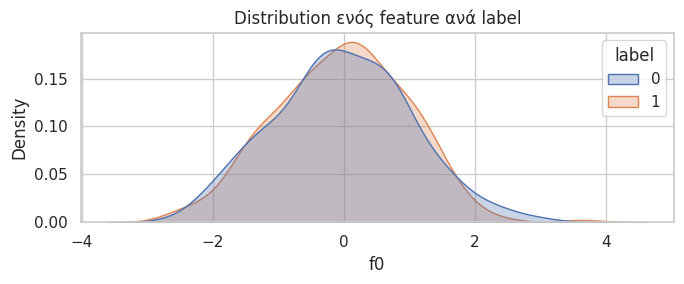

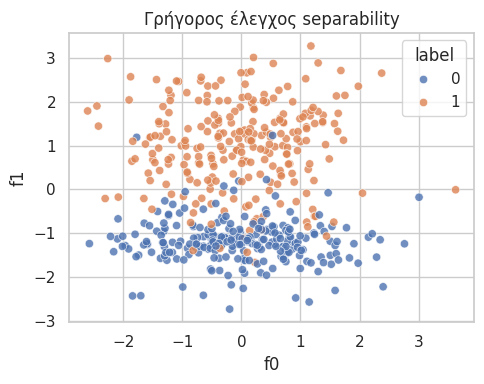

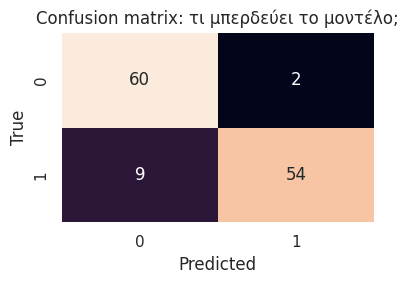

In [28]:
from sklearn.datasets import make_classification
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt
import seaborn as sns

set_seed(3)
Xv, yv = make_classification(n_samples=500, n_features=4, n_informative=2,
                             n_redundant=0, class_sep=1.2, random_state=3)
vis = pd.DataFrame(Xv, columns=["f0", "f1", "f2", "f3"])
vis["label"] = yv

# 1) Feature distribution ανά label
plt.figure(figsize=(7, 3))
sns.kdeplot(data=vis, x="f0", hue="label", fill=True, alpha=0.3)
plt.title("Distribution ενός feature ανά label")
plt.tight_layout(); plt.show()

# 2) Scatter των δύο πιο χρήσιμων features
plt.figure(figsize=(5, 4))
sns.scatterplot(data=vis, x="f0", y="f1", hue="label", alpha=0.8)
plt.title("Γρήγορος έλεγχος separability")
plt.tight_layout(); plt.show()

# 3) Confusion matrix από απλό baseline
X_train, X_val, y_train, y_val = train_test_split(Xv, yv, test_size=0.25, stratify=yv, random_state=3)
clf = Pipeline([("scaler", StandardScaler()),
                ("logreg", LogisticRegression(max_iter=1000))])
clf.fit(X_train, y_train)
pred_val = clf.predict(X_val)
cm = confusion_matrix(y_val, pred_val)

plt.figure(figsize=(4, 3))
sns.heatmap(cm, annot=True, fmt="d", cbar=False)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion matrix: τι μπερδεύει το μοντέλο;")
plt.tight_layout(); plt.show()

## 3 · Data Leakage & Adversarial Validation

**Data leakage** = όταν πληροφορία που δεν θα έχεις στην πραγματικότητα «διαρρέει» στην εκπαίδευση. Αποτέλεσμα: φανταστικό validation score, **κατάρρευση** στο πραγματικό leaderboard.

### 3α · Η απόδειξη: leakage δίνει «καλό» score από καθαρό **θόρυβο**
Παρακάτω: 200 δείγματα, 5000 **εντελώς τυχαία** χαρακτηριστικά, **τυχαίο** target. Η σωστή απάντηση είναι accuracy ≈ 0.5 (τύχη). Αν επιλέξεις «τα καλύτερα» features κοιτώντας **όλα** τα δεδομένα *πριν* το cross-validation, παίρνεις ψεύτικα υψηλό score.

In [29]:
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score, StratifiedKFold

set_seed(0)
Xr = np.random.randn(200, 5000)          # καθαρός θόρυβος
yr = np.random.randint(0, 2, 200)        # τυχαίο target -> καμία πραγματική σχέση
cv = StratifiedKFold(5, shuffle=True, random_state=0)

# ΛΑΘΟΣ: feature selection σε ΟΛΑ τα δεδομένα, ΜΕΤΑ cross-validation
sel = SelectKBest(f_classif, k=20).fit(Xr, yr)
leaky = cross_val_score(LogisticRegression(max_iter=1000), sel.transform(Xr), yr, cv=cv).mean()

# ✅ ΣΩΣΤΟ: η επιλογή ζει ΜΕΣΑ στο pipeline -> ξαναγίνεται ανεξάρτητα σε κάθε fold
pipe = Pipeline([("sel", SelectKBest(f_classif, k=20)),
                 ("clf", LogisticRegression(max_iter=1000))])
honest = cross_val_score(pipe, Xr, yr, cv=cv).mean()

print(f"❌ Με leakage:   {leaky:5.3f}   <- φαίνεται τέλειο, αλλά είναι ψέμα")
print(f"✅ Με pipeline:  {honest:5.3f}   <- η αλήθεια (~0.5 = τύχη)")

❌ Με leakage:   0.810   <- φαίνεται τέλειο, αλλά είναι ψέμα
✅ Με pipeline:  0.425   <- η αλήθεια (~0.5 = τύχη)


### 3β · Adversarial Validation — προβλέπει ποιος θα «πέσει» στο test
Ιδέα: φτιάξε έναν ταξινομητή που προσπαθεί να ξεχωρίσει **train από test**. Αυτό δουλεύει ΜΟΝΟ αν έχεις **access στα test inputs**.
- Αν δεν τα καταφέρνει (**AUC ≈ 0.5**) → ίδια κατανομή, το CV σου είναι αξιόπιστο.
- Αν τα καταφέρνει εύκολα (**AUC ≫ 0.5**) → υπάρχει **μετατόπιση/leakage**, και το `feature_importances_` σου δείχνει **ποιο feature προδίδει** το test.

In [30]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import roc_auc_score

set_seed(0)
Xtr = np.random.randn(1000, 10)
Xte = np.random.randn(1000, 10)
Xte[:, 3] += 1.0                     # κρυφή μετατόπιση κατανομής ΜΟΝΟ στο feature #3

Xall    = np.vstack([Xtr, Xte])
is_test = np.r_[np.zeros(len(Xtr)), np.ones(len(Xte))]

clf   = RandomForestClassifier(n_estimators=100, random_state=0)
proba = cross_val_predict(clf, Xall, is_test, cv=5, method="predict_proba")[:, 1]
auc   = roc_auc_score(is_test, proba)

clf.fit(Xall, is_test)
culprit = int(np.argmax(clf.feature_importances_))

print(f"Adversarial AUC = {auc:.3f}")
print("AUC≈0.5 → ίδια κατανομή | AUC≫0.5 → shift/leakage")
print(f"Το feature που προδίδει το test: #{culprit}  (βάλαμε τη μετατόπιση στο #3)")

Adversarial AUC = 0.750
AUC≈0.5 → ίδια κατανομή | AUC≫0.5 → shift/leakage
Το feature που προδίδει το test: #3  (βάλαμε τη μετατόπιση στο #3)


Οπτικοποίηση διάγνωσης: η σωστή γραφική **δεν** είναι το «ωραίο» plot — είναι αυτή που **αποκαλύπτει το πρόβλημα**. Εδώ: κατανομές train vs test, που δείχνουν με μια ματιά τη μετατόπιση.

/tmp/ipykernel_3148/3067051659.py:11: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


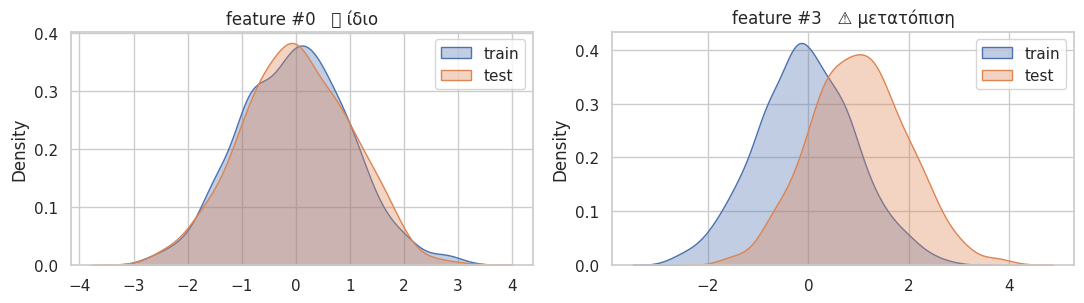

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(11, 3.2))
for f, ax in zip([0, 3], axes):
    sns.kdeplot(Xtr[:, f], label="train", ax=ax, fill=True, alpha=0.35)
    sns.kdeplot(Xte[:, f], label="test",  ax=ax, fill=True, alpha=0.35)
    ax.set_title(f"feature #{f}" + ("   ✅ ίδιο" if f == 0 else "   ⚠️ μετατόπιση"))
    ax.legend()
plt.tight_layout(); plt.show()

> **Πρακτική χρήση του adversarial validation στον διαγωνισμό:**
> - Αν AUC≫0.5: φτιάξε validation set που **μοιάζει** με το test (διάλεξε train δείγματα όπου ο ταξ. λέει «test»), ή **πέτα/διόρθωσε** τα features που προδίδουν τη μετατόπιση.


## 4 · Σωστό Cross-Validation & Pipelines

**Κανόνας χρυσός:** *το τοπικό σου CV πρέπει να κινείται μαζί με το leaderboard.* Αν δεν συμβαίνει, το CV σου είναι λάθος και «βελτιώνεις» στα τυφλά.

### 4α · `Pipeline` + `ColumnTransformer`: η προεπεξεργασία ζει **μέσα** στο fold
Έτσι δεν διαρρέει ποτέ στατιστικό (μέσος, scaler, encoder) από το validation στο train.

In [32]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

num_cols = ["minutes", "xg"]
cat_cols = ["team"]

pre = ColumnTransformer([
    ("num", Pipeline([("imp", SimpleImputer(strategy="median")), #Fill Missing valeus
                      ("sc",  StandardScaler())]), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
])

full = Pipeline([("pre", pre),
                 ("clf", LogisticRegression(max_iter=500))])

# Όλη η προεπεξεργασία κάνει fit ΜΟΝΟ στο train-fold -> μηδέν leakage στο CV.
y = (df["goals"] >= 1).astype(int)
score = cross_val_score(full, df[num_cols + cat_cols], y,
                        cv=StratifiedKFold(5, shuffle=True, random_state=0)).mean()
print(f"Honest CV accuracy (leak-free pipeline): {score:.3f}")

Honest CV accuracy (leak-free pipeline): 0.906


### 4β · Διάλεξε τον **σωστό** splitter — αλλιώς ψεύτικο score
| Κατάσταση | Splitter | Γιατί |
|-----------|----------|-------|
| Ταξινόμηση, ανεξάρτητα δείγματα | `StratifiedKFold` | διατηρεί αναλογία κλάσεων |
| Επαναλαμβανόμενες οντότητες (ίδιος παίκτης/ασθενής/εικόνα σε πολλές γραμμές) | `GroupKFold` | η ίδια οντότητα ΔΕΝ είναι ταυτόχρονα σε train & val |
| Χρονοσειρά | `TimeSeriesSplit` | εκπαίδευση μόνο στο **παρελθόν** |

**Απόδειξη γιατί το `GroupKFold` σε σώζει:** όταν η ίδια οντότητα πέφτει και στις δύο πλευρές, το μοντέλο **απομνημονεύει** αντί να γενικεύει → εξωπραγματικό score.

In [33]:
from sklearn.model_selection import GroupKFold, KFold

set_seed(0)
n_players, per = 60, 12
groups = np.repeat(np.arange(n_players), per)            # 60 "παίκτες" x 12 γραμμές
ident  = np.eye(n_players)[groups]                       # τα features ταυτοποιούν τον παίκτη
Xg = ident + 0.01 * np.random.randn(*ident.shape)
y_player = np.random.randint(0, 2, n_players)            # ΤΥΧΑΙΟ label ανά παίκτη (μη μαθήσιμο)
yg = y_player[groups]

m = LogisticRegression(max_iter=1000)
naive   = cross_val_score(m, Xg, yg, cv=KFold(5, shuffle=True, random_state=0)).mean()
grouped = cross_val_score(m, Xg, yg, cv=GroupKFold(5), groups=groups).mean()

print(f"❌ KFold   (ίδιος παίκτης σε train & val): {naive:5.3f}  <- 'απομνημόνευση', ψέμα")
print(f"✅ GroupKFold (παίκτης σε ΜΙΑ πλευρά):     {grouped:5.3f}  <- αλήθεια (~0.5)")

❌ KFold   (ίδιος παίκτης σε train & val): 1.000  <- 'απομνημόνευση', ψέμα
✅ GroupKFold (παίκτης σε ΜΙΑ πλευρά):     0.372  <- αλήθεια (~0.5)


> 🧠 **Tip:** Χρησιμοποίησε `cross_val_predict(..., method='predict_proba')` για να πάρεις **out-of-fold (OOF)** προβλέψεις. Είναι η σωστή βάση για (α) επιλογή threshold, (β) calibration, (γ) **stacking/ensembling** χωρίς leakage.

## PyTorch Tensor Manipulation Survival Kit

Αν δεν είσαι άνετος με tensors, χάνεις χρόνο σε κάθε PyTorch task. Τα βασικά που εμφανίζονται συνέχεια: `view/reshape`, `unsqueeze`, `permute`, `gather`, `topk`, `one_hot`, `detach`, `cpu`.

**Smart tips:**
- Για εικόνες, PyTorch θέλει συνήθως `(B, C, H, W)`, όχι `(B, H, W, C)`.
- Μετά από `permute`, αν θες `view`, βάλε `.contiguous()` ή χρησιμοποίησε `reshape`.
- Για classification, `CrossEntropyLoss` θέλει logits `(B, C)` και labels `(B,)` τύπου `long`.


In [34]:
import torch.nn.functional as F

set_seed(5)
# Fake batch εικόνων από NumPy/Matplotlib style: (B,H,W,C)
imgs_nhwc = torch.randn(6, 32, 32, 3)
imgs_nchw = imgs_nhwc.permute(0, 3, 1, 2).contiguous()  # PyTorch conv format

# Flatten για MLP: (B,C,H,W) -> (B, C*H*W)
flat = imgs_nchw.view(imgs_nchw.size(0), -1)

# Fake logits για 4 classes
logits = torch.randn(6, 4)
labels = torch.tensor([0, 2, 1, 3, 2, 1], dtype=torch.long)
probs = logits.softmax(dim=1)
conf, pred = probs.max(dim=1)

# Πάρε την πιθανότητα της σωστής κλάσης με gather
true_class_prob = probs.gather(1, labels[:, None]).squeeze(1)

# Top-2 predictions
values, indices = torch.topk(probs, k=2, dim=1)
one_hot_labels = F.one_hot(labels, num_classes=4).float()

print("imgs_nhwc:", imgs_nhwc.shape, "-> imgs_nchw:", imgs_nchw.shape, "-> flat:", flat.shape)
print("pred:", pred.tolist())
print("confidence:", conf.round(decimals=3).tolist())
print("true class prob:", true_class_prob.round(decimals=3).tolist())
print("top-2 indices:\n", indices)
print("one_hot shape:", one_hot_labels.shape)

assert imgs_nchw.shape == (6, 3, 32, 32)
assert flat.shape == (6, 3*32*32)
assert true_class_prob.shape == (6,)
print("Tensor manipulation checks passed")

imgs_nhwc: torch.Size([6, 32, 32, 3]) -> imgs_nchw: torch.Size([6, 3, 32, 32]) -> flat: torch.Size([6, 3072])
pred: [2, 2, 0, 1, 0, 3]
confidence: [0.5059999823570251, 0.47200000286102295, 0.5759999752044678, 0.42500001192092896, 0.4729999899864197, 0.43299999833106995]
true class prob: [0.16099999845027924, 0.47200000286102295, 0.09000000357627869, 0.12700000405311584, 0.05400000140070915, 0.11599999666213989]
top-2 indices:
 tensor([[2, 1],
        [2, 3],
        [0, 2],
        [1, 0],
        [0, 1],
        [3, 0]])
one_hot shape: torch.Size([6, 4])
Tensor manipulation checks passed


## PyTorch Basics: Dataset, DataLoader, CPU/GPU training loop

Αυτό είναι το **template** που πρέπει να ξέρετε. Αν μπορείς να το γράψεις γρήγορα, μπορείς να ξεκινήσεις σχεδόν κάθε supervised task.

**Contest-safe training loop checklist:**
- `model.train()` στο training, `model.eval()` στο validation.
- `x, y = x.to(device), y.to(device)` για CPU/GPU.
- `optimizer.zero_grad()` πριν το backward.
- `with torch.no_grad()` στο validation.
- Κράτα metrics με `.item()` ή `.detach()` για να μη φυλάς graphs στη μνήμη.


In [35]:
from torch.utils.data import TensorDataset, DataLoader
import torch.nn as nn
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_classification

set_seed(6)
Xp, yp = make_classification(n_samples=600, n_features=20, n_informative=8,
                             n_classes=3, random_state=6)
Xp = Xp.astype("float32")
yp = yp.astype("int64")
X_train, X_val, y_train, y_val = train_test_split(
    Xp, yp, test_size=0.2, stratify=yp, random_state=6
)

train_ds = TensorDataset(torch.from_numpy(X_train), torch.from_numpy(y_train))
val_ds   = TensorDataset(torch.from_numpy(X_val), torch.from_numpy(y_val))
train_loader = DataLoader(train_ds, batch_size=128, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=512, shuffle=False)

class TinyMLP(nn.Module):
    def __init__(self, in_dim=20, hidden=32, n_classes=3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden),
            nn.ReLU(),
            nn.Linear(hidden, n_classes),
        )
    def forward(self, x):
        return self.net(x)

def run_epoch(model, loader, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    total_loss, total_correct, total_n = 0.0, 0, 0
    loss_fn = nn.CrossEntropyLoss()

    context = torch.enable_grad() if is_train else torch.no_grad()
    with context:
        for xb, yb in loader:
            xb = xb.to(device)
            yb = yb.to(device)
            if is_train:
                optimizer.zero_grad()
            logits = model(xb)
            loss = loss_fn(logits, yb)
            if is_train:
                loss.backward()
                optimizer.step()

            total_loss += loss.item() * xb.size(0)
            total_correct += (logits.argmax(1) == yb).sum().item()
            total_n += xb.size(0)
    return total_loss / total_n, total_correct / total_n

model = TinyMLP().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

for epoch in range(1, 6):
    tr_loss, tr_acc = run_epoch(model, train_loader, optimizer)
    va_loss, va_acc = run_epoch(model, val_loader, optimizer=None)
    if epoch in [1, 3, 5]:
        print(f"epoch {epoch:02d} | train loss {tr_loss:.3f} acc {tr_acc:.3f} | val loss {va_loss:.3f} acc {va_acc:.3f}")

print("CPU/GPU training loop completed on", device)

epoch 01 | train loss 1.133 acc 0.331 | val loss 1.106 acc 0.417
epoch 03 | train loss 1.056 acc 0.490 | val loss 1.030 acc 0.542
epoch 05 | train loss 0.988 acc 0.571 | val loss 0.962 acc 0.608
CPU/GPU training loop completed on cuda


## 5 · PyTorch — Πώς βρίσκω bugs
### «Το μοντέλο δεν μαθαίνει.» Τι κάνεις στα **πρώτα 5 λεπτά**;

Η μεγάλη διαφορά θα γίνει όταν βρίσκετε τα bugs σε λίγα λεπτά αντί για ώρες.

### 5α · Ένα καλό check: **overfit ένα batch**
Πάρε **ένα** μικρό batch και προσπάθησε να φτάσεις loss ≈ 0. Αν δεν τα καταφέρνεις, το πρόβλημα **δεν** είναι τα δεδομένα ή το μέγεθος του μοντέλου — έχεις **bug** (στο loss, στα labels, στο optimizer, στο graph).

In [36]:
import torch.nn as nn
set_seed(0)
N, D, C = 512, 20, 3
Xt = torch.randn(N, D)
W  = torch.randn(D, C)
yt = (Xt @ W).argmax(1)                 # υπαρκτό, μαθήσιμο μοτίβο

model = nn.Sequential(nn.Linear(D, 64), nn.ReLU(), nn.Linear(64, C)).to(device)
opt   = torch.optim.Adam(model.parameters(), lr=1e-2)
lossf = nn.CrossEntropyLoss()

xb, yb = Xt[:32].to(device), yt[:32].to(device)   # ΕΝΑ batch
model.train()
for step in range(200):
    opt.zero_grad()
    loss = lossf(model(xb), yb)
    loss.backward()
    opt.step()

print(f"Loss σε 1 batch μετά από 200 βήματα: {loss.item():.5f}")
print("Έπεσε ~0 -> το pipeline εκπαίδευσης είναι ΥΓΙΕΣ.")
print("Αν ΔΕΝ έπεφτε -> bug, όχι θέμα δεδομένων.")

Loss σε 1 batch μετά από 200 βήματα: 0.00014
Έπεσε ~0 -> το pipeline εκπαίδευσης είναι ΥΓΙΕΣ.
Αν ΔΕΝ έπεφτε -> bug, όχι θέμα δεδομένων.


### 5β · Buggy-loop challenge — βρες **3 bugs**
Το παρακάτω loop *τρέχει χωρίς error* αλλά εκπαιδεύει **χάλια**. Εντόπισε τα 3 σιωπηλά λάθη. (Τα σιωπηλά bugs είναι τα επικίνδυνα — δεν σκάνε, απλά σου τρώνε το score.)

In [ ]:
# 3 BUGS εδώ μέσα. Ποια είναι;
set_seed(0)
buggy = nn.Sequential(nn.Linear(D, 64), nn.ReLU(), nn.Linear(64, C),
                      nn.Softmax(dim=1)).to(device)
opt   = torch.optim.Adam(buggy.parameters(), lr=5.0)
lossf = nn.CrossEntropyLoss()
xb, yb = Xt[:128].to(device), yt[:128].to(device)

buggy.train()
for step in range(100):
    out  = buggy(xb)
    loss = lossf(out, yb)
    loss.backward()
    opt.step()
acc = (buggy(xb).argmax(1) == yb).float().mean().item()
print(f"BUGGY  -> loss {loss.item():.4f} | train acc {acc:.3f}  (απαράδεκτο)")

BUGGY  -> loss 0.9421 | train acc 0.609  (απαράδεκτο)


**Λύση — τα 3 bugs:**
1. **`nn.Softmax` πριν το `CrossEntropyLoss`.** Το `CrossEntropyLoss` εφαρμόζει *ήδη* `log_softmax` εσωτερικά → **διπλό softmax**, σχεδόν μηδενικά gradients. ➡️ Δώσε **raw logits**.
2. **`lr=5.0`** → απόκλιση. ➡️ Λογικό `lr` (π.χ. `1e-2` με Adam).
3. **Λείπει `opt.zero_grad()`** → τα gradients **συσσωρεύονται** μεταξύ βημάτων. ➡️ Μηδένισε στην αρχή κάθε βήματος.

In [ ]:
# Διορθωμένο
set_seed(0)
fixed = nn.Sequential(nn.Linear(D, 64), nn.ReLU(), nn.Linear(64, C)).to(device)  # χωρίς Softmax
opt   = torch.optim.Adam(fixed.parameters(), lr=1e-2)                            # λογικό lr
lossf = nn.CrossEntropyLoss()

fixed.train()
for step in range(100):
    opt.zero_grad()                          # 1) μηδένισε ΠΡΩΤΑ
    loss = lossf(fixed(xb), yb)              # 2) raw logits στο loss
    loss.backward()
    opt.step()
acc = (fixed(xb).argmax(1) == yb).float().mean().item()
print(f"FIXED  -> loss {loss.item():.4f} | train acc {acc:.3f} ")

FIXED  -> loss 0.0015 | train acc 1.000 


### 5γ · Checklist «το loss δεν πέφτει»
- [ ] Έκανες **overfit ένα batch**; (αν όχι → bug, σταμάτα εδώ)
- [ ] `optimizer.zero_grad()` σε κάθε βήμα;
- [ ] Δίνεις **logits** (όχι softmax) στο `CrossEntropyLoss`; Σωστός τύπος target (`long` για classification);
- [ ] Learning rate: δοκίμασε ×10 και ÷10.
- [ ] **Κανονικοποίησες** τα inputs; (μη-κανονικοποιημένα → αργό/ασταθές)
- [ ] Έκανες `shuffle=True` στον `DataLoader` εκπαίδευσης;
- [ ] Στο validation: `model.eval()` **και** `torch.no_grad()`; (αλλιώς BatchNorm/Dropout χαλάνε το score)
- [ ] Ταιριάζουν τα **shapes** loss/labels; (broadcasting bug υπολογίζει λάθος loss χωρίς error)
- [ ] NaN; → `torch.autograd.set_detect_anomaly(True)` δείχνει **ποια πράξη** το παρήγαγε (αργό, μόνο για debug).

In [ ]:
# Σωστή ρουτίνα inference/validation
fixed.eval()                              # BatchNorm/Dropout σε λειτουργία inference
with torch.no_grad():                     # χωρίς graph -> γρηγορότερο, λιγότερη μνήμη
    preds = fixed(Xt[:64].to(device)).argmax(1)
acc = (preds.cpu() == yt[:64]).float().mean().item()
print(f"Val accuracy (σωστό eval): {acc:.3f}")
fixed.train()                             # ΞΑΝΑ σε train mode πριν συνεχίσεις την εκπαίδευση

Val accuracy (σωστό eval): 1.000


Sequential(
  (0): Linear(in_features=20, out_features=64, bias=True)
  (1): ReLU()
  (2): Linear(in_features=64, out_features=3, bias=True)
)

## 6 · GPU, Ταχύτητα & Μνήμη

Στην IOAI έχεις GPU με **όριο χρόνου και μνήμης**. Δύο λάθη που κοστίζουν: (α) κρυφός συγχρονισμός GPU→CPU, (β) σπατάλη μνήμης που οδηγεί σε **OOM** στη χειρότερη στιγμή.

### 6α · Το «κρυφό» GPU→CPU sync
Κάθε `.item()`, `.cpu()`, `print(tensor)` **μέσα στο loop** αναγκάζει τη CPU να περιμένει το GPU. Μάζεψε τα νούμερα σε tensor και κάνε `.item()` **στο τέλος** ή κάθε *N* βήματα.

In [ ]:
import time

def bench(sync_every_step: bool):
    x = torch.randn(2048, 2048, device=device)
    total = torch.zeros((), device=device)
    if device.type == "cuda": torch.cuda.synchronize()
    t = time.perf_counter()
    for _ in range(15):
        total = total + (x @ x).sum()
        if sync_every_step:
            _ = total.item()             # ← συγχρονισμός σε ΚΑΘΕ βήμα (κακό)
    if device.type == "cuda": torch.cuda.synchronize()
    return time.perf_counter() - t

if device.type == "cuda":
    a, b = bench(True), bench(False)
    print(f"Με .item() κάθε βήμα: {a:.3f}s | Χωρίς: {b:.3f}s | ➡️ ×{a/b:.1f} πιο αργό")
else:
    print("CPU runtime — άλλαξε σε GPU για να δεις τη διαφορά (Runtime ▸ Change runtime type).")

Με .item() κάθε βήμα: 0.093s | Χωρίς: 0.083s | ➡️ ×1.1 πιο αργό


### 6γ · Μνήμη & OOM
- Παρακολούθησε: `torch.cuda.memory_allocated()` / `memory_reserved()`.
- Σε OOM: μείωσε **batch size**, χρησιμοποίησε **AMP**, ή **gradient accumulation** (πολλά μικρά batches → ένα step).
- Στο validation: `torch.no_grad()` (το ξεχνούν και «σκάει» η μνήμη).
- Πρόσεξε το `loss` σε λίστα **χωρίς** `.item()` → κρατά ολόκληρο το graph στη μνήμη.

### 6δ · `DataLoader` που δεν «πεινάει» το GPU
`num_workers>0` (παράλληλη φόρτωση), `pin_memory=True`, `persistent_workers=True`, και `.to(device, non_blocking=True)`. Αν το GPU περιμένει τα δεδομένα, χάνεις χρόνο τζάμπα.

In [ ]:
if device.type == "cuda":
    a = torch.randn(2048, 2048, device=device)
    print(f"Allocated: {torch.cuda.memory_allocated()/1e6:6.0f} MB")
    print(f"Reserved : {torch.cuda.memory_reserved()/1e6:6.0f} MB")
    del a
    torch.cuda.empty_cache()         # επιστρέφει cache στο σύστημα (σπάνια αναγκαίο)
    print("Μετά το empty_cache:", f"{torch.cuda.memory_allocated()/1e6:.0f} MB allocated")
else:
    print("Εργαλεία μνήμης GPU διαθέσιμα μόνο σε GPU runtime.")

# Σκελετός σωστού DataLoader (για όταν έχεις πραγματικά δεδομένα):
# loader = torch.utils.data.DataLoader(ds, batch_size=64, shuffle=True,
#                                      num_workers=2, pin_memory=True,
#                                      persistent_workers=True)

Allocated:     35 MB
Reserved :     57 MB
Μετά το empty_cache: 18 MB allocated


### Extra H · Gradient accumulation + clipping: όταν το batch δεν χωράει

Αν παθαίνεις OOM αλλά θες effective batch size 256, κάνε 4 mini-batches των 64 και ένα optimizer step. Αυτό λέγεται **gradient accumulation**.

**Smart tip:** διαίρεσε το loss με `accum_steps`, αλλιώς αλλάζεις το effective learning rate. Για RNN/transformer-ish μοντέλα, πρόσθεσε gradient clipping.


In [ ]:
accum_steps = 4
model = TinyMLP().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.CrossEntropyLoss()

model.train()
optimizer.zero_grad()
for step, (xb, yb) in enumerate(train_loader, start=1):
    xb, yb = xb.to(device), yb.to(device)
    logits = model(xb)
    loss = loss_fn(logits, yb) / accum_steps
    loss.backward()

    if step % accum_steps == 0 or step == len(train_loader):
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        optimizer.zero_grad()

print("Gradient accumulation template ran")

Gradient accumulation template ran


# 7 · ML Training Tips

Αυτή η ενότητα δεν βασίζεται σε συγκεκριμένο IOAI task.
Αντίθετα, δείχνει πρακτικά patterns που εμφανίζονται σε γενικα ML tasks:

---

Θα φτιάξουμε ένα μικρό fake tabular classification dataset.
Το target είναι αν ένας παίκτης θα σκοράρει ή όχι.


In [ ]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, roc_auc_score, ConfusionMatrixDisplay
from sklearn.inspection import permutation_importance

np.random.seed(42)

n = 1200

minutes = np.random.gamma(shape=2.0, scale=25.0, size=n)
shots = np.random.poisson(lam=2.0, size=n)

xg = 0.10 * shots + np.random.normal(0, 0.15, size=n)
xg = np.clip(xg, 0, None)

teams = np.random.choice(
    ["A", "B", "C", "D"],
    size=n,
    p=[0.35, 0.25, 0.25, 0.15]
)

# True probability of scoring
logit = (
    -2.0
    + 0.025 * minutes
    + 1.8 * xg
    + 0.25 * (teams == "A")
    - 0.20 * (teams == "D")
)

prob = 1 / (1 + np.exp(-logit))
goals = np.random.binomial(1, prob)

df = pd.DataFrame({
    "minutes": minutes,
    "shots": shots,
    "xg": xg,
    "team": teams,
    "goals": goals
})

df.head()



### 7.2 Πρώτο reflex: sanity check

Πριν φτιάξουμε οποιοδήποτε μοντέλο, κοιτάμε:

πόσες γραμμές και στήλες έχουμε,
τι τύπο έχει κάθε column,
αν έχουμε missing values,
αν το target είναι balanced ή imbalanced,
μερικές πρώτες γραμμές.

In [12]:

def quick_sanity(df, target=None):
    print("Shape:", df.shape)

    print("\nDtypes:")
    print(df.dtypes)

    print("\nMissing values:")
    print(df.isna().sum().sort_values(ascending=False))

    if target is not None:
        print(f"\nTarget distribution: {target}")
        print(df[target].value_counts(normalize=True).rename("proportion"))

    print("\nHead:")
    display(df.head())


quick_sanity(df, target="goals")


NameError: name 'df' is not defined

### 7.3 Δημιουργούμε missing data επίτηδες

Θα βάλουμε missing values με δύο διαφορετικούς τρόπους.


*   Το xg θα λείπει τυχαία.

*   Το minutes θα λείπει πιο συχνά όταν ο παίκτης έχει λίγα λεπτά.




Η δεύτερη περίπτωση είναι σημαντική:
το ίδιο το γεγονός ότι κάτι λείπει μπορεί να είναι πληροφορία.

In [ ]:
df_missing = df.copy()

rng = np.random.default_rng(123)

# xg missing completely at random
mask_xg = rng.random(n) < 0.12
df_missing.loc[mask_xg, "xg"] = np.nan

# minutes missing not completely at random:
# more likely missing when minutes are low
missing_prob_minutes = np.where(df["minutes"] < 30, 0.30, 0.05)
mask_minutes = rng.random(n) < missing_prob_minutes
df_missing.loc[mask_minutes, "minutes"] = np.nan

quick_sanity(df_missing, target="goals")

In [ ]:
#πού έχω missing values;

missing_counts = df_missing.isna().sum().sort_values(ascending=False)

plt.figure(figsize=(7, 4))
missing_counts[missing_counts > 0].plot(kind="bar")
plt.title("Missing values per column")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

### 7.4 Είναι το missingness correlated με το target;

Αν οι γραμμές όπου λείπει ένα feature έχουν διαφορετικό target rate, τότε το missingness ίσως είναι χρήσιμη πληροφορία.

In [ ]:

tmp = df_missing.copy()

tmp["minutes_is_missing"] = tmp["minutes"].isna().astype(int)
tmp["xg_is_missing"] = tmp["xg"].isna().astype(int)

print("Goal rate by whether minutes is missing:")
display(tmp.groupby("minutes_is_missing")["goals"].mean())


print("Goal rate by whether xg is missing:")
display(tmp.groupby("xg_is_missing")["goals"].mean())

#Αν το minutes_is_missing = 1 έχει πολύ διαφορετικό goal rate από το minutes_is_missing = 0,
#τότε ίσως πρέπει να κρατήσουμε missing indicator.

### 7.5 Compare missing-data strategies correctly

Θα συγκρίνουμε τέσσερις στρατηγικές:


*   Drop rows with missing values.

*   Median imputation.

*   Median imputation + missing indicators.

*   KNN imputation.



Σημαντικό: όλα αυτά πρέπει να γίνουν μέσα σε Pipeline, ώστε το imputer να κάνει fit μόνο στο train fold.
Αλλιώς έχουμε data leakage.

In [ ]:

X = df_missing[["minutes", "shots", "xg", "team"]]
y = df_missing["goals"]

num_cols = ["minutes", "shots", "xg"]
cat_cols = ["team"]

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


def evaluate_pipeline(name, pipe, X, y):
    scores = cross_val_score(pipe, X, y, cv=cv, scoring="roc_auc")
    print(f"{name:35s} AUC = {scores.mean():.3f} ± {scores.std():.3f}")
    return scores.mean()


# Strategy 1: Drop rows with missing values

drop_df = df_missing.dropna()

X_drop = drop_df[["minutes", "shots", "xg", "team"]]
y_drop = drop_df["goals"]

pre_drop = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
])

pipe_drop = Pipeline([
    ("pre", pre_drop),
    ("clf", LogisticRegression(max_iter=1000))
])


# Strategy 2: Median imputation

pre_median = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]), num_cols),

    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
])

pipe_median = Pipeline([
    ("pre", pre_median),
    ("clf", LogisticRegression(max_iter=1000))
])


# Strategy 3: Median imputation + missing indicators

pre_indicator = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
        ("scaler", StandardScaler())
    ]), num_cols),

    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
])

pipe_indicator = Pipeline([
    ("pre", pre_indicator),
    ("clf", LogisticRegression(max_iter=1000))
])


# Strategy 4: KNN imputation

pre_knn = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", KNNImputer(n_neighbors=5)),
        ("scaler", StandardScaler())
    ]), num_cols),

    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
])

pipe_knn = Pipeline([
    ("pre", pre_knn),
    ("clf", LogisticRegression(max_iter=1000))
])


results = {}

results["drop rows"] = evaluate_pipeline("Drop rows", pipe_drop, X_drop, y_drop)
results["median imputation"] = evaluate_pipeline("Median imputation", pipe_median, X, y)
results["median + indicators"] = evaluate_pipeline("Median + missing indicators", pipe_indicator, X, y)
results["KNN imputation"] = evaluate_pipeline("KNN imputation", pipe_knn, X, y)

pd.Series(results).sort_values(ascending=False)



#Στο διαγωνισμό:

#Start with median imputation.
#Add missing indicators if missingness may be informative.
#Do not use dropna() automatically.
#KNN imputation is sometimes useful, but slower and not always better.

# 8 · Playbook Διαγωνισμού

### Στρατηγικές που οι περισσότεροι δεν εφαρμόζουν συστηματικά

**A. Baseline ΠΡΩΤΑ, μετά έξυπνα κόλπα.** Στείλε κάτι απλό που τρέχει **στα πρώτα 20 λεπτά** (π.χ. logistic regression / μικρό MLP / pretrained backbone + linear head). Έχεις score αναφοράς και ελέγχεις ότι το pipeline submission δουλεύει. *Partial credit για κώδικα που τρέχει - οπότε πάντα να έχεις «κάτι».*

**B. Αξιοποίησε pretrained μοντέλα — μην εκπαιδεύεις από το μηδέν.** Τα IOAI tasks συχνά λύνονται γρηγορότερα με **έτοιμα features** παρά με training από το μηδέν:
- Images: pretrained CNN/ViT embeddings + linear head.
- NLP: sentence/BERT embeddings + logistic regression ή μικρό classifier.
- Tabular: `HistGradientBoosting`, `RandomForest`, `LogisticRegression` με σωστό preprocessing.
- Retrieval: normalized embeddings + cosine similarity.